#### Exercise 1
Hugo Lladró Prats, Inés Mang Román, Ahmet Meriç Kızıltaş

Plotly is a plotting library with bindings for different programming languages. It enables the creation
of interactive plots based on HTML, CSS and javascript. An introduction to the parallel coordinates
plot with plotly can be found here: https://plotly.com/python/parallel-coordinates-plot/
In this exercises, we will work with a Mice Protein Expression Dataset, which contains expression levels
of 77 proteins, measured in the cerebral cortex of 8 classes of mice. The classes result from two genotypes
(Ts65Dn, which serves as a mouse model of human down syndrome, vs. normal controls), two treatments
(injection of the drug memantine vs. a saline solution as a control), and two experimental conditions
related to context fear conditioning (context-shock, which should lead to learning, vs. shock-context, in
which no learning takes place). Counting all repeated measurements, there are 1080 samples overall,
some with missing data. You can find more information on the data in the corresponding publication.

In [1]:
#We begin by installing plotly
!mamba install plotly
!mamba install pandas
!mamba install xlrd
!mamba install nbformat

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, plotly
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.943 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ narwhals                      2.20.0                        pyhcf101f3_0                  conda-forge                   
+ plotly                        6.6.0                         pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, plotly, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solvin

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xlrd
import plotly.express as px

In [48]:
!mamba list nbformat

Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
asttokens                     3.0.1                         pyhd8ed1ab_0                  conda-forge                   
attrs                         26.1.0                        pyhcf101f3_0                  conda-forge                   
backcall                      0.2.0                         pyh9f0ad1d_0                  conda-forge                   
branca                        0.8.2                         pyhd8ed1ab_0                  conda-forge                   
comm                          0.2.3                         pyhe01879c_0                  conda-forge                   
contourpy                     1.3.3                         py313h3a67976_1               emscripten-forge              
cycler                        0.

**a)** *Use pandas to read the file Data_Cortex_Nuclear.xls provided via eCampus. Extract subgroups
t-CS-s and c-CS-s. How many mice were measured for each class? (1P)*


In [3]:
data = pd.read_excel("Data_Cortex_Nuclear.xls", index_col = 0)
data.head()

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
MouseID,,,,,,,,,,,,,,,,,,,,,
309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [4]:
data = pd.concat([data[(data["class"] == 'c-CS-s')],data[(data["class"] == 't-CS-s')]])
data["class"].value_counts()

class
c-CS-s    135
t-CS-s    105
Name: count, dtype: int64

There are 135 measurements of mouses of the class *c-CS-s* and 105 of the class *t-CS-s*.

**b)** *Create a parallel coordinates plot with plotly from the following 5 proteins: (pPKCG N, pP70S6 N,
pS6 N, pGSK3B N, ARC N). Assign different colors to the two selected classes. Annotate every
axis with the correct protein name. (9P)*

In [5]:
data.insert(0, "class_id", [(0 if i == 'c-CS-s' else 1) for i in data["class"]])

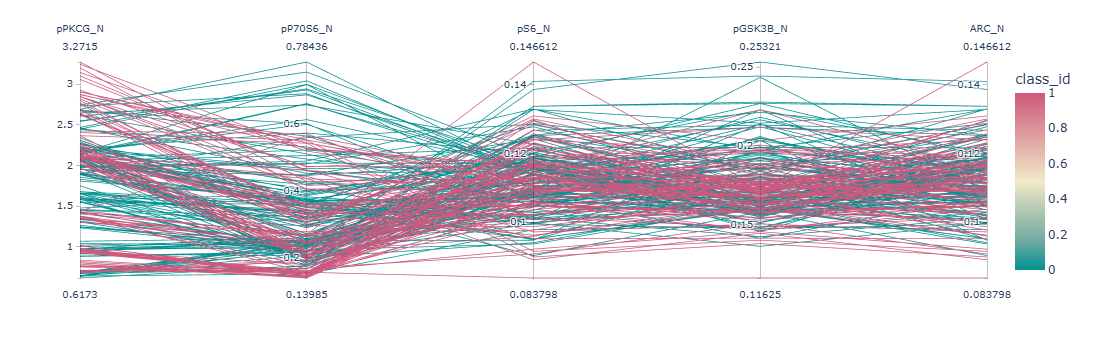

In [9]:
fig = px.parallel_coordinates(data, color="class_id",
                              dimensions=['pPKCG_N', 'pP70S6_N','pS6_N', 'pGSK3B_N','ARC_N'],
                              color_continuous_scale=px.colors.diverging.Tealrose)
fig.show()

**c)** *Explore the data by interacting with the parallel coordinates plot. Do you find anything suspicious
about the data set? (1P)*

The data set looks fairly normal to me. We see the data points evenly distributed around the range of the variables, and even though the subgroups have different distributions, the correlation between variables seems to be the same in all cases(positive, negative, positive, positive). We have some apparent outliers: an individual on group 1 with low values on all proteins, another individual on group 1 that has a particularly high value on protein pS6_N, and 2 individuals on group 0 with high values on proteins pS6_N, pGSK3B_N and ARC_N